#Oscar Data Pipeline | ETL e Integração de APIs com Python

Este projeto tem como objetivo construir um pipeline de dados utilizando informações dos indicados ao Oscar de Melhor Filme Internacional e dados da API de países do IBGE.

O processo envolve coleta, transformação, integração e análise dos dados, com foco no enriquecimento das informações dos filmes a partir de dados geográficos dos países.

## 1. Importação das bibliotecas

Nesta etapa são importadas as bibliotecas necessárias para manipulação de dados, requisições HTTP e leitura de tabelas.

In [3]:
import pandas as pd
import requests

## 2. Extração dos dados do Oscar

A base principal do projeto contém os filmes indicados ao Oscar de Melhor Filme Internacional, incluindo ano da cerimônia, filme e país concorrente.

Os dados serão extraídos diretamente da Wikipédia utilizando o Pandas.

requests.get() : solicita a página.
headers : envia informações junto à requisição.
User-Agent : identifica o tipo de cliente fazendo a solicitação.
status_code : mostra se a requisição funcionou.

In [4]:
url_oscar = "https://pt.wikipedia.org/wiki/Lista_dos_indicados_ao_Oscar_de_melhor_filme_internacional"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url_oscar, headers=headers)

print(response.status_code)

200


agora utilizamos o HTML que já está dentro de response e passar para o Pandas. utilizaremos um objeto de texto para a manipulação de pandas, vamos usar StringIO

In [5]:
from io import StringIO

tabelas_oscar = pd.read_html(StringIO(response.text))

print(f"Quantidade de tabelas encontradas: {len(tabelas_oscar)}")

Quantidade de tabelas encontradas: 14


depois disso precisamos saber quais dessas tabelas são realmente as tabelas de indicados.

In [6]:
for i, tabela in enumerate(tabelas_oscar):
    print(f"\n--- Tabela {i} ---")
    print(tabela.head(3))


--- Tabela 0 ---
           Ano             Filme           Direção País concorrente Língua(s)  \
0  1948 (20.ª)  Sciuscià[nota 3]  Vittorio De Sica           Itália  Italiano   
1  1949 (21.ª)  Monsieur Vincent    Maurice Cloche           França   Francês   

   Ref.  
0  [10]  
1  [11]  

--- Tabela 1 ---
           Ano                                    Filme           Direção  \
0  1950 (22.ª)                      Ladri di biciclette  Vittorio De Sica   
1  1951 (23.ª)  Au-delà des grilles Le mura di Malapaga      René Clément   
2  1952 (24.ª)                             Rashōmon 羅生門    Akira Kurosawa   

  País concorrente           Língua(s)  Ref.  
0           Itália            Italiano  [12]  
1  França & Itália  Francês e Italiano  [13]  
2            Japão             Japonês  [14]  

--- Tabela 2 ---
           Ano             Filme          Direção    País concorrente  \
0  1960 (32.ª)       Orfeu Negro     Marcel Camus              França   
1  1960 (32.ª)        Die Brü

## 3. Consolidação das tabelas do Oscar

A página da Wikipédia organiza os indicados em diferentes tabelas por período. Como as tabelas de índice 0 a 8 possuem a mesma estrutura, elas serão concatenadas em um único DataFrame.

In [7]:
oscar = pd.concat(tabelas_oscar[0:9], ignore_index=True)

oscar.head()

,Ano,Filme,Direção,País concorrente,Língua(s),Ref.
0,1948 (20.ª),Sciuscià[nota 3],Vittorio De Sica,Itália,Italiano,[10]
1,1949 (21.ª),Monsieur Vincent,Maurice Cloche,França,Francês,[11]
2,1950 (22.ª),Ladri di biciclette,Vittorio De Sica,Itália,Italiano,[12]
3,1951 (23.ª),Au-delà des grilles Le mura di Malapaga,René Clément,França & Itália,Francês e Italiano,[13]
4,1952 (24.ª),Rashōmon 羅生門,Akira Kurosawa,Japão,Japonês,[14]


conferimos o tamnho da nossa base de dados (linhas, colunas)

In [8]:
oscar.shape

(359, 6)

columns: nome das colunas

In [9]:
oscar.columns

Index(['Ano', 'Filme', 'Direção', 'País concorrente', 'Língua(s)', 'Ref.'], dtype='object')

tail(): confirmação se os dados mais recentes também entraram na concatenação.

In [10]:
oscar.tail()

,Ano,Filme,Direção,País concorrente,Língua(s),Ref.
354,2026 (98.ª),O Agente Secreto,Kleber Mendonça Filho,Brasil,Português,[87]
355,2026 (98.ª),Un Simple Accident,Jafar Panahi,França,Persa / Azeri,[87]
356,2026 (98.ª),Sirāt,Óliver Laxe,Espanha,Espanhol / Francês,[87]
357,2026 (98.ª),Ṣawt Hind Rajab,Kaouther Ben Hania,Tunísia,Árabe,[87]
358,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Limpeza e preparação dos dados do Oscar

Antes da integração com a API do IBGE, é necessário verificar valores ausentes, ajustar campos e preparar as colunas que serão utilizadas no merge.

In [11]:
oscar.isnull().sum()

,0
Ano,1
Filme,1
Direção,1
País concorrente,1
Língua(s),1
Ref.,1


removemos linhas totalmente vazias

how="all" : O Pandas interpreta para excluir uma linha somente se todas as colunas forem NaN.

In [12]:
oscar = oscar.dropna(how="all")

agora, vamos conferir novamente o conteúdo

In [13]:
oscar.shape

(358, 6)

## Transformação -> ETL

### 4.1 Tratamento da coluna Ano

A coluna "Ano" contém, além do ano da cerimônia, a edição correspondente do Oscar. Para facilitar análises posteriores, será mantido apenas o ano e o campo será convertido para o tipo inteiro.

str.extract(r"(\d{4})"): procura uma sequência de exatamente 4 números dentro do texto. e o astype(int): transforma o resultado de texto para número inteiro.

In [15]:
oscar["Ano"] = oscar["Ano"].str.extract(r"(\d{4})")
oscar["Ano"] = oscar["Ano"].astype(int)

validação

In [16]:
oscar[["Ano", "Filme", "País concorrente"]].head(10)

,Ano,Filme,País concorrente
0,1948,Sciuscià[nota 3],Itália
1,1949,Monsieur Vincent,França
2,1950,Ladri di biciclette,Itália
3,1951,Au-delà des grilles Le mura di Malapaga,França & Itália
4,1952,Rashōmon 羅生門,Japão
5,1953,Jeux interdits,França
6,1955,Jigokumon 地獄門,Japão
7,1956,Miyamoto Musashi 宮本武蔵,Japão
8,1957,La strada,Itália
9,1957,Der Hauptmann von Köpenick,Alemanha Ocidental


conferindo o tipo de dado está corretamente

In [17]:
oscar.dtypes

,0
Ano,int64
Filme,object
Direção,object
País concorrente,object
Língua(s),object
Ref.,object


conerindo o país concorrente

In [18]:
oscar["País concorrente"].nunique()

67

o resultado nos mostra quantos países diferentes aparecem e quais são eles.

In [19]:
paises_oscar = sorted(oscar["País concorrente"].unique())

paises_oscar

['Alemanha',
 'Alemanha Ocidental',
 'Alemanha Oriental',
 'Argentina',
 'Argélia',
 'Austrália',
 'Brasil',
 'Butão',
 'Bélgica',
 'Bósnia e Herzegovina',
 'Camboja',
 'Canadá',
 'Cazaquistão',
 'Checoslováquia',
 'Chile',
 'China',
 'Chéquia',
 'Colômbia',
 'Coreia do Sul',
 'Costa do Marfim',
 'Cuba',
 'Dinamarca',
 'Espanha',
 'Estónia',
 'Finlândia',
 'França',
 'França & Itália',
 'Geórgia',
 'Grécia',
 'Hong Kong',
 'Hungria',
 'Irlanda',
 'Irão',
 'Islândia',
 'Israel',
 'Itália',
 'Iugoslávia',
 'Japão',
 'Jordânia',
 'Letónia',
 'Líbano',
 'Macedônia do Norte',
 'Mauritânia',
 'México',
 'Nepal',
 'Nicarágua',
 'Noruega',
 'Palestina',
 'Países Baixos',
 'Peru',
 'Polónia',
 'Polônia',
 'Porto Rico',
 'Reino Unido',
 'Roménia',
 'Rússia',
 'Suécia',
 'Suíça',
 'Taiwan',
 'Tchecoslováquia',
 'Tunísia',
 'União Soviética',
 'Uruguai',
 'Vietname',
 'África do Sul',
 'Áustria',
 'Índia']

observamos 3 situações nesses 67 valores: Variação de escrita, Países históricos e Casos especiais.

## 5. Extração dos dados externos — API do IBGE

Para enriquecer a base do Oscar com informações geográficas, será utilizada a API de países do IBGE.

Os dados retornados em formato JSON serão convertidos para uma estrutura tabular utilizando Pandas.

In [20]:
url_ibge = "https://servicodados.ibge.gov.br/api/v1/paises"

response_ibge = requests.get(url_ibge)

print(response_ibge.status_code)

200


In [21]:
dados_ibge = response_ibge.json()

type(dados_ibge)

list

conferimos 1 único país antes da transformação em DataFrame

In [22]:
dados_ibge[0]

{'id': {'M49': 20, 'ISO-3166-1-ALPHA-2': 'AD', 'ISO-3166-1-ALPHA-3': 'AND'},
 'nome': {'abreviado': 'Andorra',
  'abreviado-EN': 'Andorra',
  'abreviado-ES': 'Andorra'},
 'area': {'total': '468',
  'unidade': {'nome': 'quilômetros quadrados',
   'símbolo': 'km2',
   'multiplicador': 1}},
 'localizacao': {'regiao': {'id': {'M49': 150}, 'nome': 'Europa'},
  'sub-regiao': {'id': {'M49': 39},
   'nome': 'Europa meridional  (Sul da Europa)'},
  'regiao-intermediaria': None},
 'linguas': [{'id': {'ISO-639-1': 'ca', 'ISO-639-2': 'cat'},
   'nome': 'catalão'}],
 'governo': {'capital': {'nome': 'Andorra-a-Velha'}},
 'unidades-monetarias': [{'id': {'ISO-4217-ALPHA': 'EUR',
    'ISO-4217-NUMERICO': '978'},
   'nome': 'Euro'}],
 'historico': 'O Principado de Andorra é um dos menores Estados da Europa, situado no alto dos Pireneus, entre as fronteiras francesa e espanhola. O primeiro documento que menciona Andorra é a Ata de Consagração da Catedral de Santa María de Urgell, de 839. Tal documento no

### 5.1 Normalização do JSON

Como os dados retornados pela API do IBGE possuem uma estrutura JSON aninhada, foi utilizada a função `pd.json_normalize()` para convertê-los em formato tabular.

Foram mantidos apenas os campos necessários para o enriquecimento da base do Oscar: nome do país, região, sub-região e códigos ISO.

transformamos em um DataFrame

In [23]:
ibge = pd.json_normalize(dados_ibge)

selecionamos os campos mais relevantes para a análise

In [24]:
ibge = ibge[
    [
        "nome.abreviado",
        "localizacao.regiao.nome",
        "localizacao.sub-regiao.nome",
        "id.ISO-3166-1-ALPHA-2",
        "id.ISO-3166-1-ALPHA-3"
    ]
]

e renomeamos para váriaveis mais legíveis

In [25]:
ibge = ibge.rename(columns={
    "nome.abreviado": "pais_ibge",
    "localizacao.regiao.nome": "regiao",
    "localizacao.sub-regiao.nome": "sub_regiao",
    "id.ISO-3166-1-ALPHA-2": "iso2",
    "id.ISO-3166-1-ALPHA-3": "iso3"
})

conferimos o retorno do resultado com as 5 primeiras linhas

In [26]:
ibge.head()

,pais_ibge,regiao,sub_regiao,iso2,iso3
0,Andorra,Europa,Europa meridional (Sul da Europa),AD,AND
1,Emirados Árabes Unidos,Ásia,Ásia ocidental (Oeste da Ásia),AE,ARE
2,Afeganistão,Ásia,Ásia meridional (Sul da Ásia),AF,AFG
3,Antígua e Barbuda,América,América Latina e Caribe,AG,ATG
4,Albânia,Europa,Europa meridional (Sul da Europa),AL,ALB


enfim, chegamos na parte mais importante em que comparamos os nomes dos países do Oscar com os nomes do IBGE antes de fazer o merge.

In [27]:
paises_ibge = sorted(ibge["pais_ibge"].dropna().unique())

paises_ibge

['Afeganistão',
 'Albânia',
 'Alemanha',
 'Andorra',
 'Angola',
 'Antígua e Barbuda',
 'Argentina',
 'Argélia',
 'Armênia',
 'Arábia Saudita',
 'Austrália',
 'Azerbaijão',
 'Bahamas',
 'Bangladesh',
 'Barbados',
 'Barein',
 'Belarus',
 'Belize',
 'Benin',
 'Bolívia',
 'Botsuana',
 'Brasil',
 'Brunei',
 'Bulgária',
 'Burkina Faso',
 'Burundi',
 'Butão',
 'Bélgica',
 'Bósnia e Herzegovina',
 'Cabo Verde',
 'Camarões',
 'Camboja',
 'Canadá',
 'Catar',
 'Cazaquistão',
 'Chade',
 'Chile',
 'China',
 'Chipre',
 'Colômbia',
 'Comores',
 'Costa Rica',
 'Costa do Marfim',
 'Croácia',
 'Cuba',
 'Dinamarca',
 'Djibouti',
 'Dominica',
 'Egito',
 'El Salvador',
 'Emirados Árabes Unidos',
 'Equador',
 'Eritreia',
 'Eslováquia',
 'Eslovênia',
 'Espanha',
 'Estados Unidos da América',
 'Estônia',
 'Eswatini',
 'Etiópia',
 'Fiji',
 'Filipinas',
 'Finlândia',
 'França',
 'Gabão',
 'Gana',
 'Geórgia',
 'Granada',
 'Grécia',
 'Guatemala',
 'Guiana',
 'Guiné',
 'Guiné Equatorial',
 'Guiné-Bissau',
 'Gâmbia

esta linha nos mostra quais países existem no Oscar mas não encontram correspondência exata no IBGE.

In [28]:
set(paises_oscar) - set(paises_ibge)

{'Alemanha Ocidental',
 'Alemanha Oriental',
 'Checoslováquia',
 'Chéquia',
 'Coreia do Sul',
 'Estónia',
 'França & Itália',
 'Hong Kong',
 'Irão',
 'Iugoslávia',
 'Letónia',
 'Palestina',
 'Polónia',
 'Porto Rico',
 'Roménia',
 'Rússia',
 'Taiwan',
 'Tchecoslováquia',
 'União Soviética',
 'Vietname'}

### 6. Validação das chaves de integração

Antes da realização do merge, os nomes dos países presentes na base do Oscar foram comparados com os nomes retornados pela API do IBGE.

Foram identificadas diferenças de grafia, nomenclaturas históricas e casos especiais que impedem uma correspondência direta entre as bases.

conferimos como o IBGE chama alguns países atuais que deveriam existir na API

In [29]:
termos = [
    "Coreia",
    "Rússia",
    "Russa",
    "Tche",
    "Ché",
    "Est",
    "Ir",
    "Let",
    "Pol",
    "Rom",
    "Viet",
    "Hong",
    "Palest",
    "Taiwan",
    "Porto"
]

for termo in termos:
    resultado = ibge[
        ibge["pais_ibge"]
        .str.contains(termo, case=False, na=False)
    ]["pais_ibge"].tolist()

    if resultado:
        print(f"{termo}: {resultado}")

Coreia: ['República Popular Democrática da Coreia', 'República da Coreia']
Rússia: ['Rússia (Federação Russa)']
Russa: ['Rússia (Federação Russa)']
Tche: ['República Tcheca']
Est: ['Estônia', 'Timor-Leste', 'Estados Unidos da América']
Ir: ['Emirados Árabes Unidos', 'Irlanda', 'Iraque', 'Irã', 'Quirguistão', 'Kiribati']
Let: ['Letônia']
Pol: ['Polônia']
Rom: ['Romênia']
Viet: ['Vietnã']


In [30]:
paises_sem_correspondencia = set(paises_oscar) - set(paises_ibge)

len(paises_sem_correspondencia)

20

### 6.1 Padronização dos nomes dos países

Foram identificadas diferenças de nomenclatura entre a base do Oscar e a API do IBGE. Para permitir o merge, os nomes foram padronizados com base nas denominações utilizadas pela API.

In [31]:
mapa_paises = {
    "Coreia do Sul": "República da Coreia",
    "Rússia": "Rússia (Federação Russa)",
    "Chéquia": "República Tcheca",
    "Estónia": "Estônia",
    "Irão": "Irã",
    "Letónia": "Letônia",
    "Polónia": "Polônia",
    "Roménia": "Romênia",
    "Vietname": "Vietnã"
}

criamos uma nova coluna e preservamos a informação original e cria uma versão preparada para a integração

In [32]:
oscar["pais_padronizado"] = oscar["País concorrente"].replace(mapa_paises)

testamos novamente quais países ainda não foram encontrados correspondência:

In [33]:
paises_padronizados = set(oscar["pais_padronizado"].unique())

faltantes = paises_padronizados - set(paises_ibge)

sorted(faltantes)

['Alemanha Ocidental',
 'Alemanha Oriental',
 'Checoslováquia',
 'França & Itália',
 'Hong Kong',
 'Iugoslávia',
 'Palestina',
 'Porto Rico',
 'Taiwan',
 'Tchecoslováquia',
 'União Soviética']

### 6.2 Tratamento de países históricos e casos especiais

Após a padronização ortográfica, permaneceram países e territórios sem correspondência direta na API atual do IBGE.

Entre eles estão antigas entidades políticas, como União Soviética, Iugoslávia e Alemanha Ocidental, além de territórios e casos de indicação multinacional.

Esses registros foram analisados separadamente para evitar associações incorretas com países atuais.

vamos verificar quantas vezes cada caso especial aparece na base

In [34]:
oscar[
    oscar["pais_padronizado"].isin(faltantes)
]["pais_padronizado"].value_counts()

,count
pais_padronizado,
União Soviética,9
Alemanha Ocidental,8
Iugoslávia,6
Checoslováquia,4
Taiwan,3
Hong Kong,3
Palestina,2
Tchecoslováquia,2
França & Itália,1


In [35]:
oscar[
    oscar["pais_padronizado"].isin(faltantes)
][["Ano", "Filme", "País concorrente"]].sort_values("Ano")

,Ano,Filme,País concorrente
3,1951,Au-delà des grilles Le mura di Malapaga,França & Itália
9,1957,Der Hauptmann von Köpenick,Alemanha Ocidental
14,1958,"Nachts, wenn der Teufel kam",Alemanha Ocidental
19,1959,Helden,Alemanha Ocidental
21,1959,La strada lunga un anno Cesta duga godinu dana...,Iugoslávia
24,1960,Die Brücke,Alemanha Ocidental
32,1961,Deveti krug Девети круг,Iugoslávia
53,1966,Obchod na korze,Checoslováquia
60,1967,Lásky jedné plavovlásky,Checoslováquia
62,1967,Tri Три,Iugoslávia


temos 3 grupos diferentes:Históricos: Alemanha Ocidental, Alemanha Oriental, Checoslováquia/Tchecoslováquia, Iugoslávia e União Soviética.
Territórios/casos geopolíticos: Hong Kong, Palestina, Porto Rico e Taiwan.
Caso multinacional: França & Itália.

padronizaos checoslováquia e tchecoslováquia

In [36]:
oscar["pais_padronizado"] = oscar["pais_padronizado"].replace({
    "Checoslováquia": "Tchecoslováquia"
})

## 7. Integração dos dados

A base do Oscar foi integrada aos dados geográficos da API do IBGE utilizando um `merge` do tipo `left`.

Esse tipo de junção preserva todos os registros do Oscar, mesmo quando não existe correspondência na API do IBGE.

Alguns países históricos, territórios e casos especiais permaneceram sem enriquecimento geográfico para evitar associações incorretas com países atuais.

In [37]:
oscar_enriquecido = oscar.merge(
    ibge,
    left_on="pais_padronizado",
    right_on="pais_ibge",
    how="left"
)

validamos quantos registros ficaram sem enriquecimento:

In [38]:
oscar_enriquecido["sub_regiao"].isna().sum()

np.int64(40)

e buscamos quais são:

In [39]:
oscar_enriquecido[
    oscar_enriquecido["sub_regiao"].isna()
][
    ["Ano", "Filme", "País concorrente", "pais_padronizado"]
].sort_values("Ano")

,Ano,Filme,País concorrente,pais_padronizado
3,1951,Au-delà des grilles Le mura di Malapaga,França & Itália,França & Itália
9,1957,Der Hauptmann von Köpenick,Alemanha Ocidental,Alemanha Ocidental
14,1958,"Nachts, wenn der Teufel kam",Alemanha Ocidental,Alemanha Ocidental
19,1959,Helden,Alemanha Ocidental,Alemanha Ocidental
21,1959,La strada lunga un anno Cesta duga godinu dana...,Iugoslávia,Iugoslávia
24,1960,Die Brücke,Alemanha Ocidental,Alemanha Ocidental
32,1961,Deveti krug Девети круг,Iugoslávia,Iugoslávia
53,1966,Obchod na korze,Checoslováquia,Tchecoslováquia
60,1967,Lásky jedné plavovlásky,Checoslováquia,Tchecoslováquia
62,1967,Tri Три,Iugoslávia,Iugoslávia


## 8. Análise dos indicados por sub-região

Após o enriquecimento da base do Oscar com os dados geográficos do IBGE, os registros foram agrupados por sub-região para identificar quais regiões concentram o maior número de indicações ao Oscar de Melhor Filme Internacional.

##8.1 Contagem por sub-região

In [40]:
indicados_subregiao = (
    oscar_enriquecido
    .groupby("sub_regiao")
    .size()
    .reset_index(name="numero_indicados")
    .sort_values("numero_indicados", ascending=False)
)

indicados_subregiao

,sub_regiao,numero_indicados
4,Europa ocidental (Oeste da Europa),80
3,Europa meridional (Sul da Europa),63
6,Europa setentrional (Norte da Europa),46
5,Europa oriental (Leste da Europa),34
0,América Latina e Caribe,30
13,Ásia oriental (Leste da Ásia),21
12,Ásia ocidental (Oeste da Ásia),14
11,Ásia meridional (Sul da Ásia),8
8,África setentrional (Norte da África),7
1,América do Norte,7


.groupby("sub_regiao"): Agrupa todos os filmes que pertencem à mesma sub-região.

.size(): Conta quantos registros existem em cada grupo.

.reset_index(name="numero_indicados"): Transforma o resultado novamente em um DataFrame e chama a contagem de numero_indicados.

.sort_values("numero_indicados", ascending=False): ordena do maior para o menor, exatamente como o exercício pede.

##8.2 Vamos calcular também o percentual

In [42]:
indicados_subregiao["percentual"] = (
    indicados_subregiao["numero_indicados"]
    / indicados_subregiao["numero_indicados"].sum()
    * 100
).round(2)

indicados_subregiao

,sub_regiao,numero_indicados,percentual
4,Europa ocidental (Oeste da Europa),80,25.16
3,Europa meridional (Sul da Europa),63,19.81
6,Europa setentrional (Norte da Europa),46,14.47
5,Europa oriental (Leste da Europa),34,10.69
0,América Latina e Caribe,30,9.43
13,Ásia oriental (Leste da Ásia),21,6.60
12,Ásia ocidental (Oeste da Ásia),14,4.40
11,Ásia meridional (Sul da Ásia),8,2.52
8,África setentrional (Norte da África),7,2.20
1,América do Norte,7,2.20


validação devido o groupby() ignorar o NaN, os países históricos e casos especiais não entram na contagem.

In [43]:
total_oscar = len(oscar_enriquecido)
total_classificado = oscar_enriquecido["sub_regiao"].notna().sum()
total_nao_classificado = oscar_enriquecido["sub_regiao"].isna().sum()

print(f"Total de indicações: {total_oscar}")
print(f"Indicações classificadas por sub-região: {total_classificado}")
print(f"Indicações sem classificação: {total_nao_classificado}")

Total de indicações: 358
Indicações classificadas por sub-região: 318
Indicações sem classificação: 40


##8.3 Resultado da análise

In [44]:
indicados_subregiao

,sub_regiao,numero_indicados,percentual
4,Europa ocidental (Oeste da Europa),80,25.16
3,Europa meridional (Sul da Europa),63,19.81
6,Europa setentrional (Norte da Europa),46,14.47
5,Europa oriental (Leste da Europa),34,10.69
0,América Latina e Caribe,30,9.43
13,Ásia oriental (Leste da Ásia),21,6.60
12,Ásia ocidental (Oeste da Ásia),14,4.40
11,Ásia meridional (Sul da Ásia),8,2.52
8,África setentrional (Norte da África),7,2.20
1,América do Norte,7,2.20


##8.4 Participação da Europa

As quatro primeiras posições são sub-regiões europeias:

Europa Ocidental: 80,
Europa Meridional: 63,
Europa Setentrional: 46,
Europa Oriental: 34

In [45]:
indicacoes_europa = (
    oscar_enriquecido[
        oscar_enriquecido["regiao"] == "Europa"
    ]
    .shape[0]
)

indicacoes_europa

223

calculamos a participação e obtemos aproximadamente 70.1%

In [46]:
percentual_europa = (
    indicacoes_europa
    / oscar_enriquecido["sub_regiao"].notna().sum()
    * 100
)

round(percentual_europa, 2)

np.float64(70.13)

##8.5 Ranking por região

In [47]:
indicados_regiao = (
    oscar_enriquecido
    .groupby("regiao")
    .size()
    .reset_index(name="numero_indicados")
    .sort_values("numero_indicados", ascending=False)
)

indicados_regiao

,regiao,numero_indicados
1,Europa,223
4,Ásia,46
0,América,37
3,África,11
2,Oceania,1


##8.6 Visualização

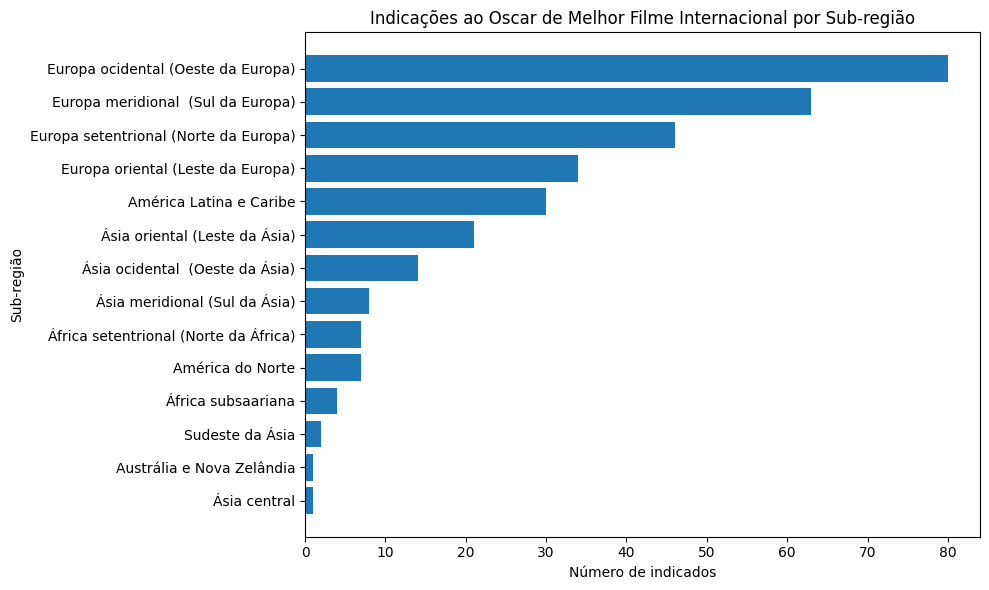

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    indicados_subregiao["sub_regiao"],
    indicados_subregiao["numero_indicados"]
)

plt.xlabel("Número de indicados")
plt.ylabel("Sub-região")
plt.title("Indicações ao Oscar de Melhor Filme Internacional por Sub-região")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Principais insights

A análise evidencia uma forte concentração das indicações em países europeus. As quatro sub-regiões da Europa ocupam as primeiras posições do ranking, com destaque para a Europa Ocidental, responsável por 80 indicações, seguida pela Europa Meridional, com 63.

Entre as regiões não europeias, a América Latina e Caribe apresenta a maior participação, com 30 indicações, ocupando a quinta posição geral. Na Ásia, a maior concentração ocorre na Ásia Oriental, com 21 indicações.

Também é possível observar uma participação significativamente menor de regiões como África Subsaariana, Sudeste Asiático, Ásia Central e Austrália e Nova Zelândia.

Os resultados indicam, portanto, uma distribuição geográfica desigual entre os indicados ao Oscar de Melhor Filme Internacional, com predominância das sub-regiões europeias no conjunto de dados analisado.

##10.O projeto permitiu construir um pipeline de dados integrando informações de diferentes fontes. A base principal, contendo os indicados ao Oscar de Melhor Filme Internacional, foi coletada por meio de web scraping e posteriormente tratada e consolidada com Python e Pandas.

Para enriquecer os dados, foi utilizada a API de países do IBGE. Os dados retornados em formato JSON foram normalizados e integrados à base do Oscar por meio de um merge, acrescentando informações geográficas como região, sub-região e códigos ISO.

Durante a integração, foram identificadas diferenças de nomenclatura entre as duas fontes, além de países históricos e casos especiais sem correspondência direta na API atual. Esses registros foram validados e tratados de forma a preservar a integridade dos dados, evitando associações incorretas.

A análise final mostrou uma forte concentração das indicações nas sub-regiões europeias, especialmente na Europa Ocidental e Europa Meridional. Entre as regiões não europeias, América Latina e Caribe apresentou a maior quantidade de indicações.

O desenvolvimento deste projeto envolveu etapas de extração, transformação, integração, validação e análise de dados, aplicando conceitos de ETL, consumo de API REST, tratamento de JSON, web scraping, manipulação de dados com Pandas e enriquecimento de dados.